In [55]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [57]:
import os

print(os.listdir())

['.config', 'top10_states.png', '.ipynb_checkpoints', 'SampleSuperstore.csv', 'profit_by_category.png', 'sales_by_region.png', 'monthly_sales_trend.png', 'sales_vs_profit.png', 'sample_data', 'discount_vs_profit.png', 'profit_boxplot.png', 'sales_by_category.png', 'correlation_heatmap.png', 'quantity_distribution.png', 'Sample - Superstore.csv']


In [58]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [59]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nInformation:")
df.info()

Dataset Shape: (9994, 21)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  

In [60]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [61]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [62]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [63]:
df["Order Date"].head()

,Order Date
0,2016-11-08
1,2016-11-08
2,2016-06-12
3,2015-10-11
4,2015-10-11


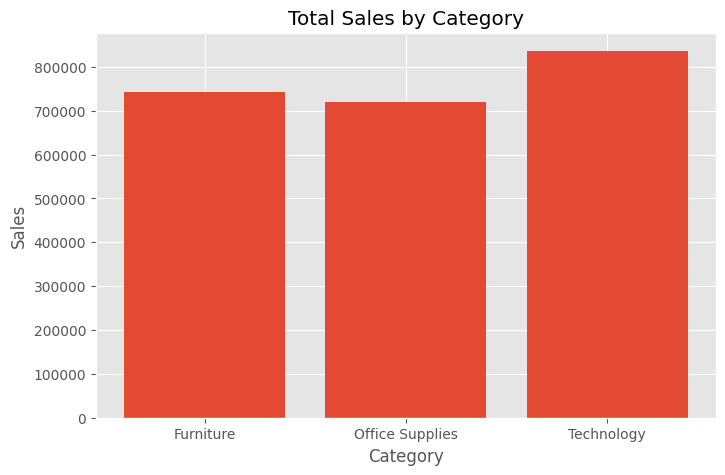

In [64]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_category.index, sales_category.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

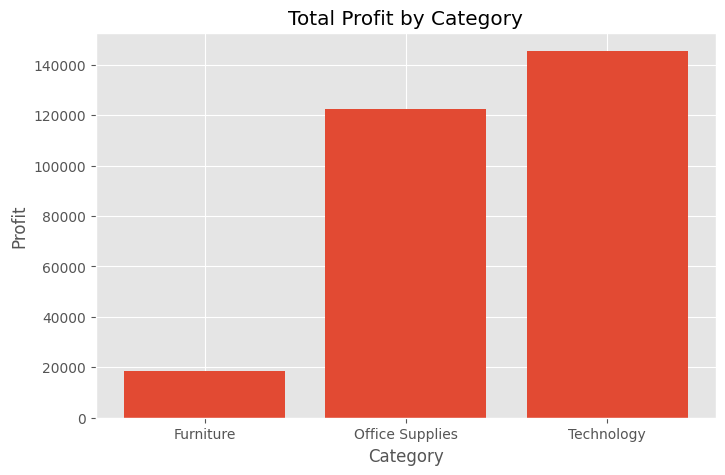

In [65]:
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

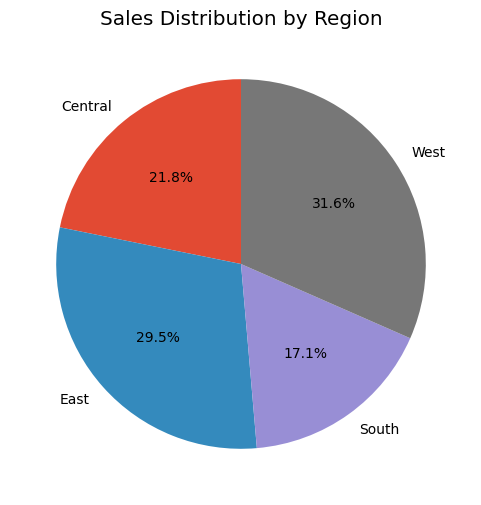

In [66]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,6))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Region")

plt.show()

In [67]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [68]:
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

monthly_sales.head()

,Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


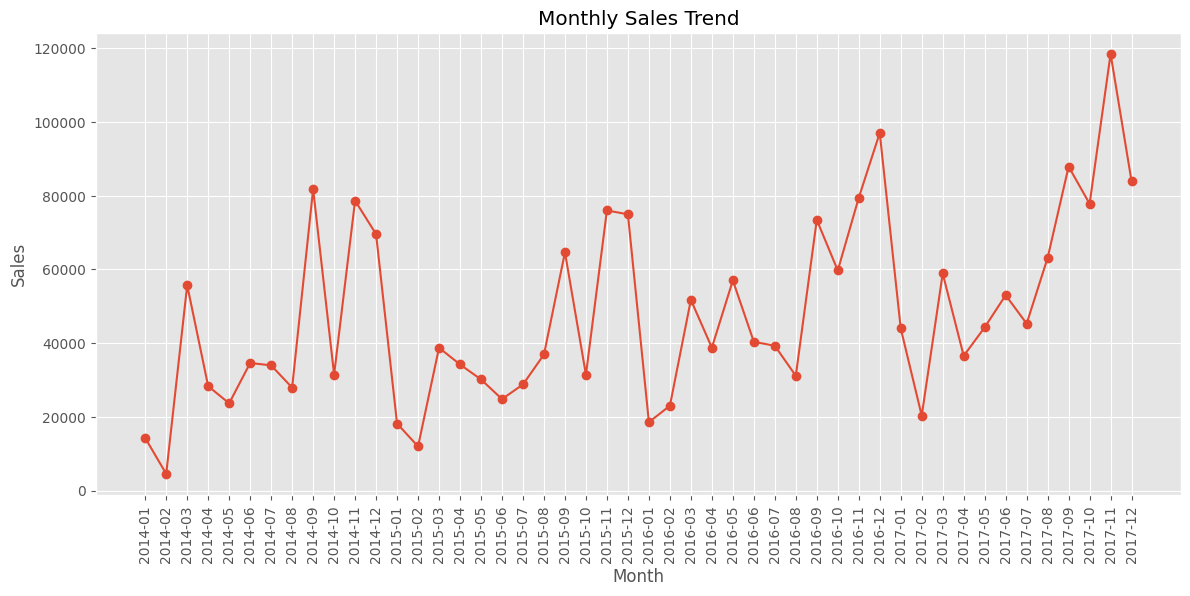

In [69]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Month"], monthly_sales["Sales"], marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.show()

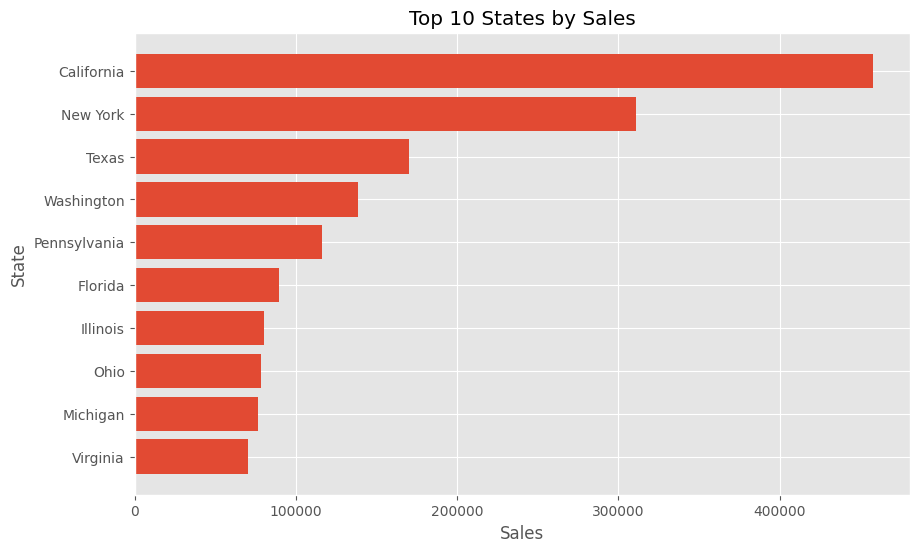

In [70]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top_states.index, top_states.values)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.show()

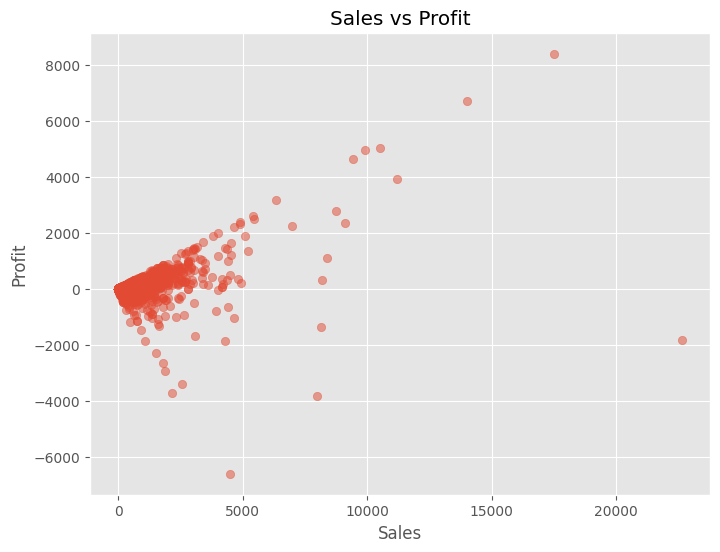

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit")

plt.xlabel("Sales")

plt.ylabel("Profit")

plt.show()

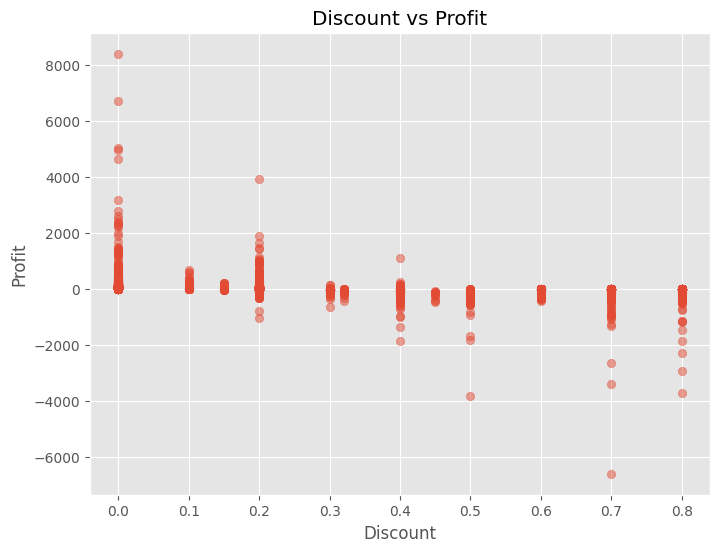

In [72]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

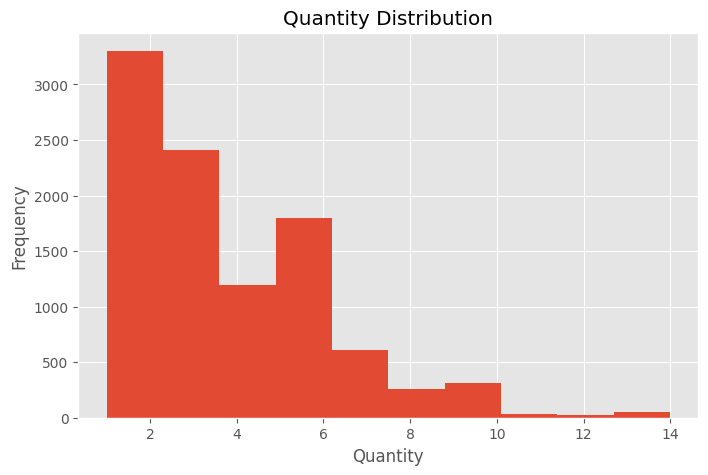

In [73]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=10)

plt.title("Quantity Distribution")

plt.xlabel("Quantity")

plt.ylabel("Frequency")

plt.show()

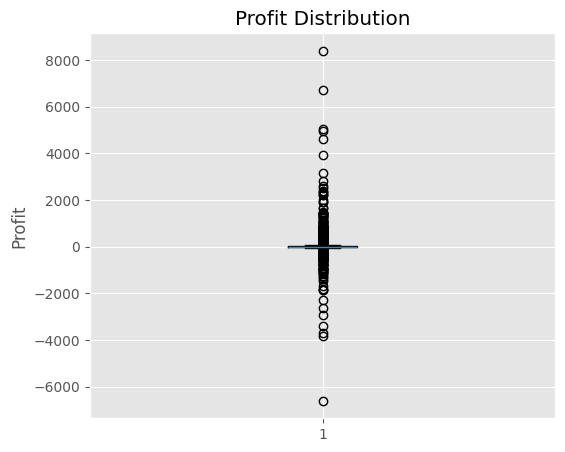

In [74]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution")

plt.ylabel("Profit")

plt.show()

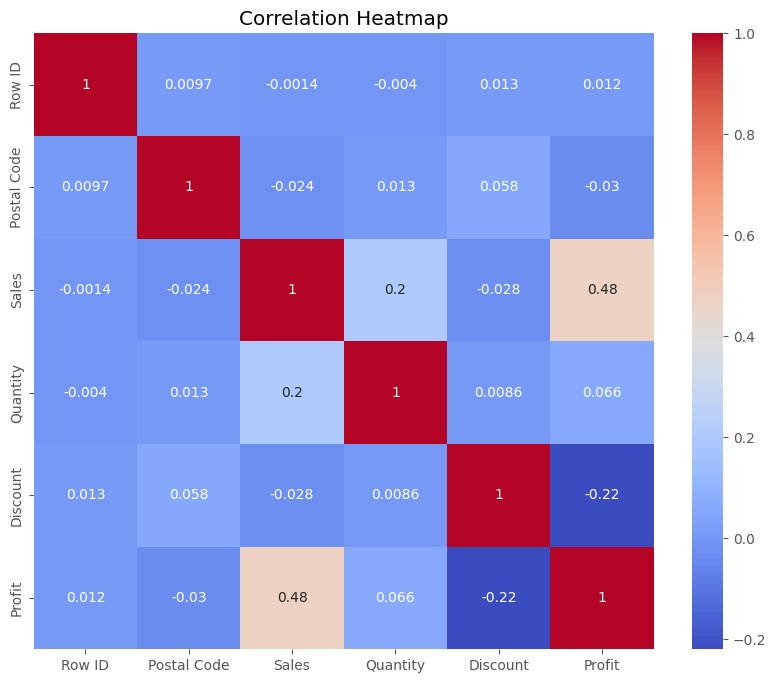

In [75]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

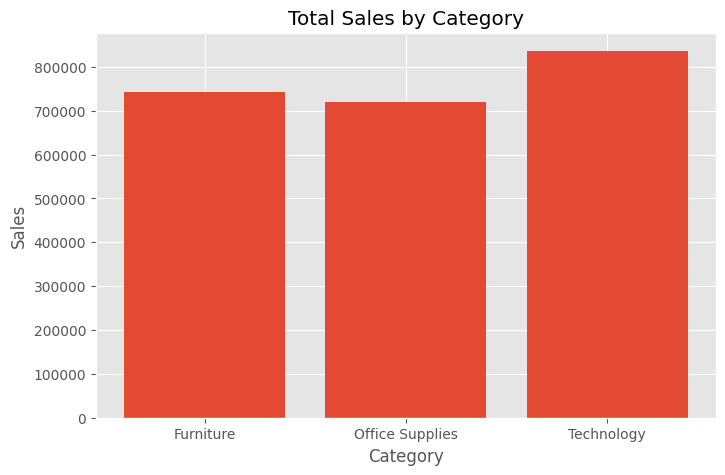

In [76]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8,5))
plt.bar(sales_category.index, sales_category.values)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.savefig("sales_by_category.png")
plt.show()

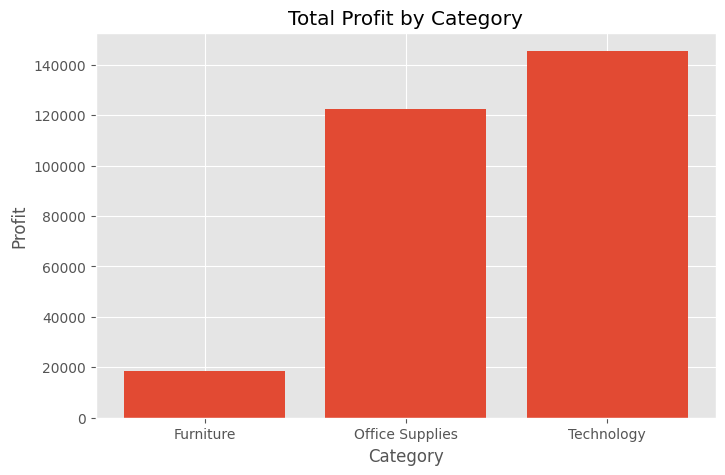

In [77]:
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8,5))
plt.bar(profit_category.index, profit_category.values)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.savefig("profit_by_category.png")
plt.show()

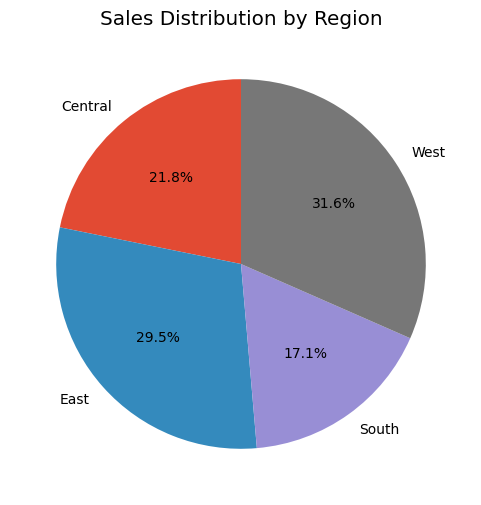

In [78]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,6))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Region")

plt.savefig("sales_by_region.png")
plt.show()

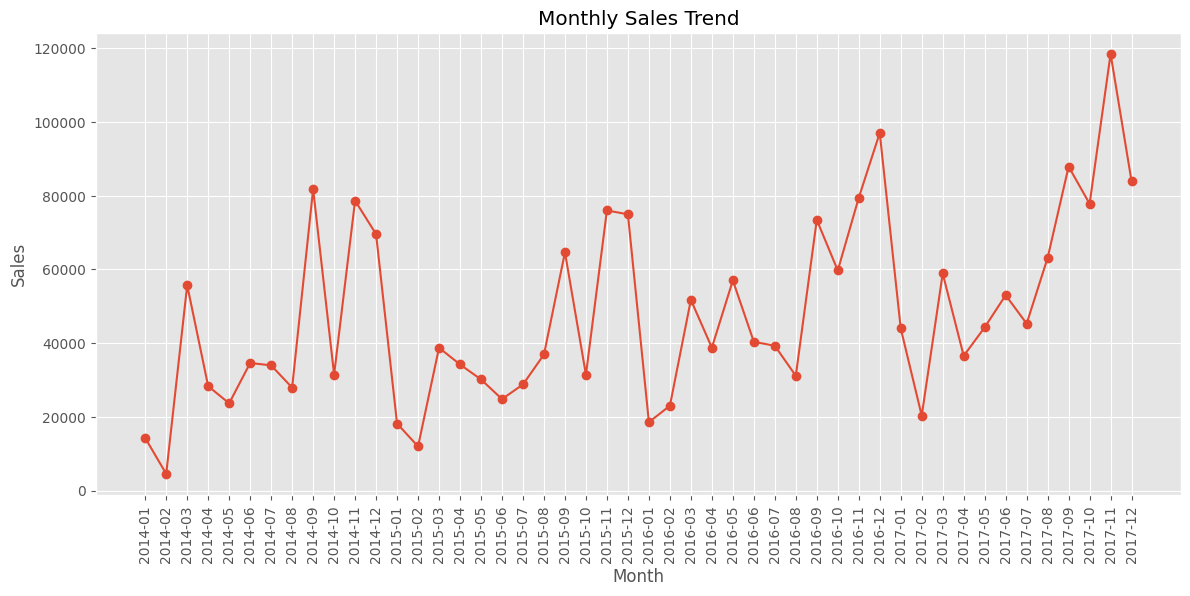

In [79]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Month"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.savefig("monthly_sales_trend.png")
plt.show()

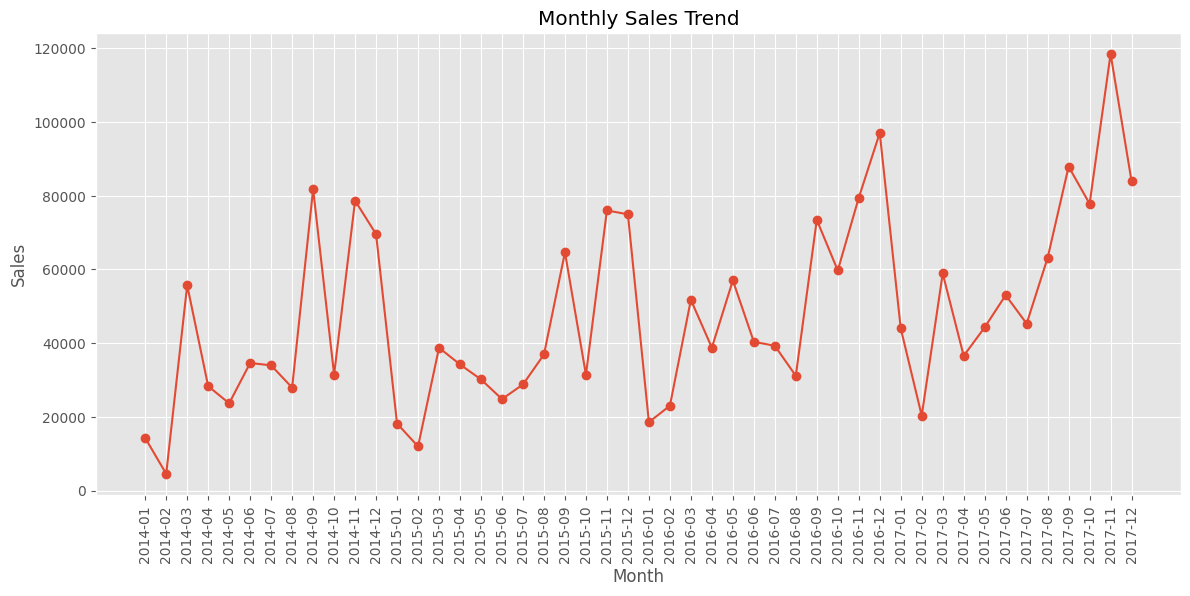

In [80]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Month"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.grid(True)

plt.savefig("monthly_sales_trend.png")
plt.show()

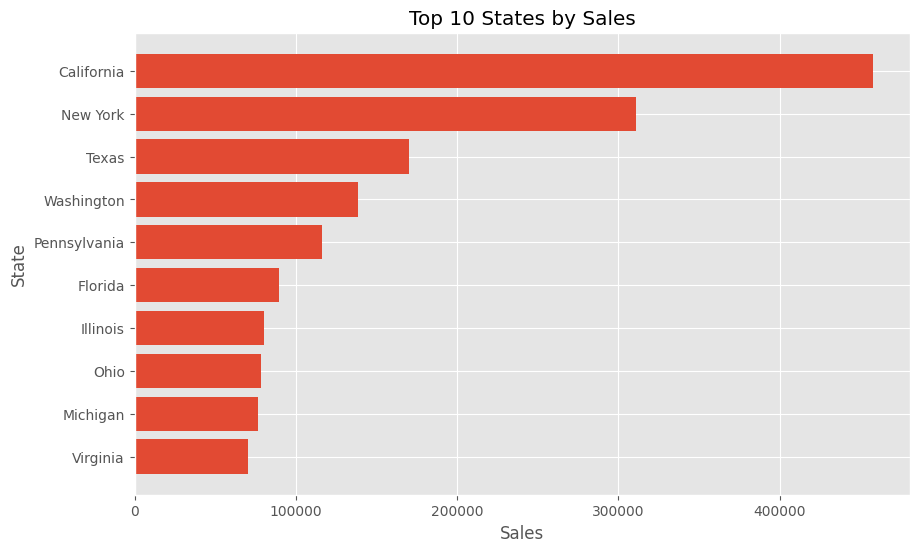

In [81]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top_states.index,
         top_states.values)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.savefig("top10_states.png")
plt.show()

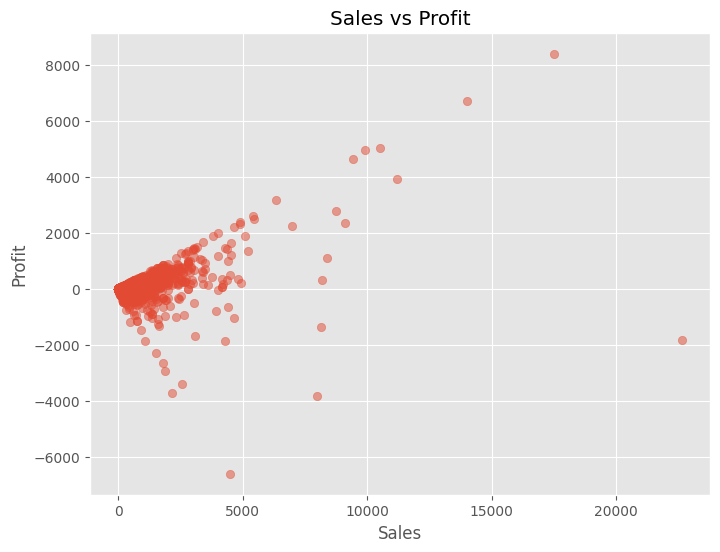

In [82]:
plt.figure(figsize=(8,6))

plt.scatter(df["Sales"],
            df["Profit"],
            alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.savefig("sales_vs_profit.png")
plt.show()

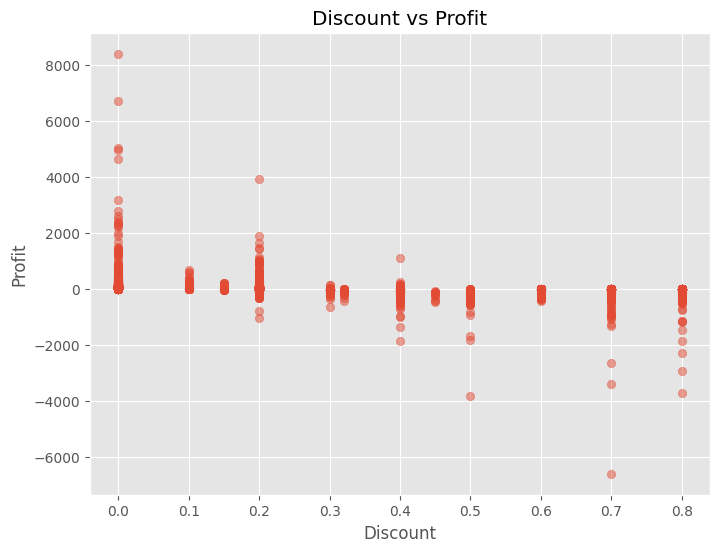

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(df["Discount"],
            df["Profit"],
            alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.savefig("discount_vs_profit.png")
plt.show()

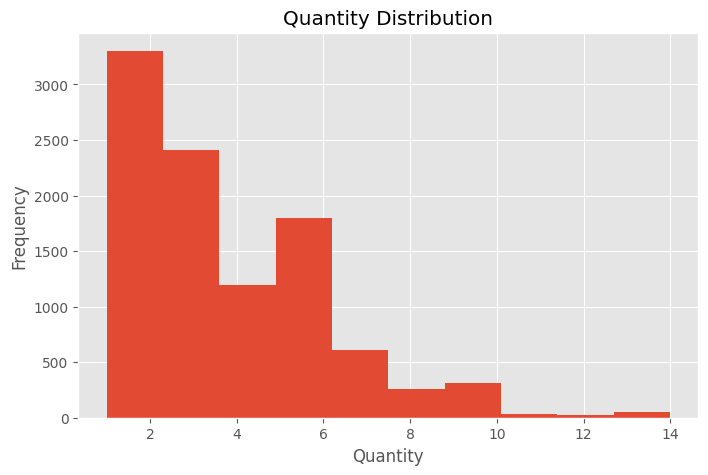

In [84]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"],
         bins=10)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.savefig("quantity_distribution.png")
plt.show()

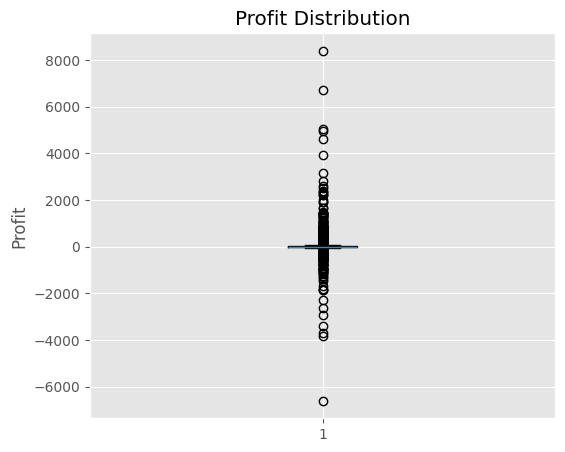

In [85]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Profit"])

plt.title("Profit Distribution")
plt.ylabel("Profit")

plt.savefig("profit_boxplot.png")
plt.show()

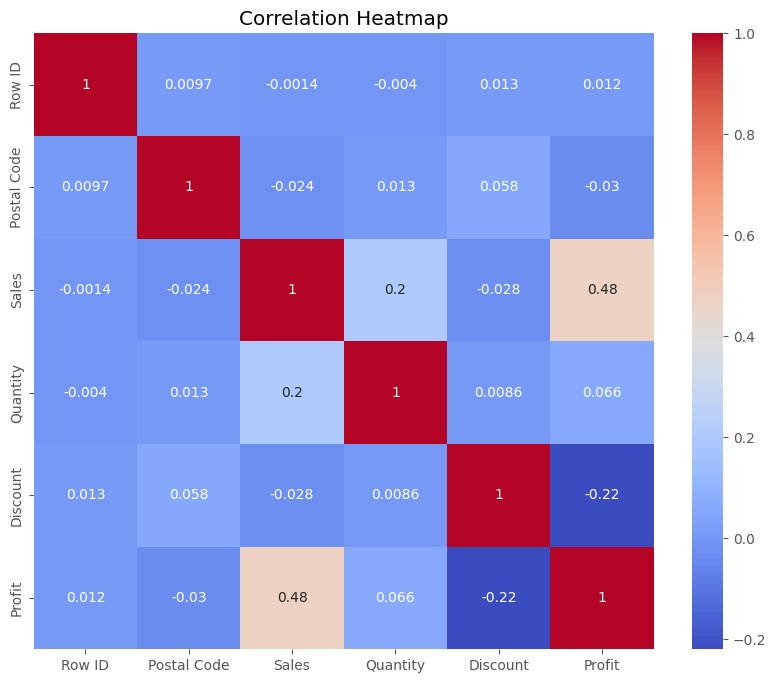

In [86]:
numeric_df = df.select_dtypes(include=["number"])

correlation = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

In [87]:
import os

print(os.listdir())

['.config', 'top10_states.png', '.ipynb_checkpoints', 'SampleSuperstore.csv', 'profit_by_category.png', 'sales_by_region.png', 'monthly_sales_trend.png', 'sales_vs_profit.png', 'sample_data', 'discount_vs_profit.png', 'profit_boxplot.png', 'sales_by_category.png', 'correlation_heatmap.png', 'quantity_distribution.png', 'Sample - Superstore.csv']


In [88]:
from google.colab import files

files.download("sales_by_category.png")
files.download("profit_by_category.png")
files.download("sales_by_region.png")
files.download("monthly_sales_trend.png")
files.download("top10_states.png")
files.download("sales_vs_profit.png")
files.download("discount_vs_profit.png")
files.download("quantity_distribution.png")
files.download("profit_boxplot.png")
files.download("correlation_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
from google.colab import files
files.download("SampleSuperstore.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>